findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


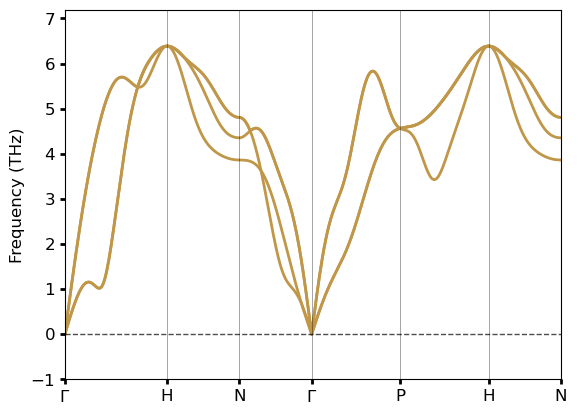

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('Nb.freq.gp')
cm_to_thz = 0.0299792458

for band in range(1, 4):
    plt.plot(data[:, 0], data[:, band] * cm_to_thz, linewidth=2, alpha=1, color='#C09748')

plt.plot(data[:, 0], data[:, 3] * cm_to_thz, linewidth=2, alpha=1, color='#C09748')

plt.axvline(x=data[0, 0], linewidth=0.5, color='r', alpha=0.5)
plt.axvline(x=data[100, 0], linewidth=0.5, color='k', alpha=0.5)
plt.axvline(x=data[200, 0], linewidth=0.5, color='k', alpha=0.5)
plt.axvline(x=data[300, 0], linewidth=0.5, color='k', alpha=0.5)  # Changed from 300 to 301
plt.axvline(x=data[400, 0], linewidth=0.5, color='k', alpha=0.5)  # Changed from 400 to 401
plt.axvline(x=data[500, 0], linewidth=0.5, color='k', alpha=0.5) 
plt.axvline(x=data[600, 0], linewidth=0.5, color='k', alpha=0.5) 



plt.xticks(ticks=[0, data[100, 0], data[200, 0], data[300, 0], data[400, 0], data[500, 0], data[600, 0]],
           labels=['$\Gamma$', 'H', 'N', '$\Gamma$', 'P', 'H', 'N'],
           fontname='Arial', fontsize=12)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.ylabel("Frequency (THz)", fontname='Arial', fontsize=12)
plt.xlim(data[0, 0], data[-1, 0])
plt.ylim(-1, 240 * cm_to_thz)
plt.tick_params(axis='both', which='major', labelsize=12, width=2)
plt.tick_params(axis='both', which='minor', labelsize=10, width=2)
plt.show()

In [ ]:
phonopy-load phonopy_params_q2r.yaml --bands="0.000 0.000 0.000 
  0.5 -0.5 0.5      
  0.0 0.0 0.5       
  0.000 0.000 0.000 
  0.25 0.25 0.25    
  0.5 -0.5 0.5       
  0.0 0.0 0.5" -p -s --writefc --hdf5

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pymatgen.core import Structure, Lattice
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from ase.io import read, write
from ase.visualize import view

In [4]:
# Read the VASP file
#atoms = read('NbN_primitive.vasp', format='vasp')
s0 = read('scf.in', format='espresso-in')

# Visualize the structure
#view(atoms)

# Write to Quantum ESPRESSO input format
#write('NbN.in', atoms, format='espresso-in')
write('scf.vasp', s0, format='vasp')

In [2]:
s1 = Structure.from_file('scf.vasp')
print(s1)

Full Formula (Nb1)
Reduced Formula: Nb
abc   :   2.868178   2.868178   2.868178
angles: 109.471221 109.471221 109.471221
pbc   :       True       True       True
Sites (1)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  Nb      0    0    0


In [ ]:
python make_q2r_fc.py scf.in Nb.fc --expected-a 2.868178 --units ev-ang